In [184]:
import cobra 
from thermo_flux.io import load_excel as ex
import thermo_flux
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('/home/nathan/PhD/04.Computational/202601_13C/3_src/')
import analysis.io_func as io_func
import seaborn as sns

We converted the stoichiometric model in notebook 1a with Thermo-flux, and performed thermodynamically constrained flux variability analyses (TFVA). These TFVA were done while applying physiological data only (TSM, P) or physiological and metabolome data (TSM, P,M). Both cases were also done for 2 different growth conditions, here Glucose and Acetate. 

Physiological data is from Jose Losa thesis (2024), metabolome data is from Kochanowski (2017).

### In this notebook, we compare the reaction directions/flux ranges between 
- The initial reaction direction as taken from the BiGG model iJR904 and the directions returned by TSM, P+M for both conditions 
- TSM,P and TSM, P+M for one condition (GLC)
- TSM, P+M results between the two growth conditions (GLC, AC)

this notebook results in figure 7b



In [185]:
PLOTTING_DATA_FOLDER='data_forplotting/'

In [186]:
#formating
cfg,_=io_func.import_plotconfigs()
sns.set_palette('viridis')
OUTPUT_FOLDER='./Figures/'
def scale_rcparams(fig,scalingf=None):
    default_figsize = (5, 5)
    current_figsize = fig.get_size_inches()
    scale_x = current_figsize[0] / default_figsize[0]
    scale_y = current_figsize[1] / default_figsize[1]
    scale = min(scale_x, scale_y) if scalingf is None else scalingf
    
    # Update rcParams with scaled values
    plt.rcParams['axes.linewidth'] = 2.05 * scale
    plt.rcParams['lines.linewidth'] = 1.5 * scale
    plt.rcParams['font.size'] = 12.5# 25 * scale #fixed size of 12.5 for all
    plt.rcParams['xtick.major.size'] = 9.84 * scale
    plt.rcParams['ytick.major.size'] = 9.84 * scale
    plt.rcParams['xtick.minor.size'] = 6.56 * scale
    plt.rcParams['ytick.minor.size'] = 6.56 * scale
    #width
    # 'ytick.minor.width': 1.0
    plt.rcParams['xtick.major.width'] = 2.05 * scale
    plt.rcParams['ytick.major.width'] = 2.05 * scale
    plt.rcParams['xtick.minor.width'] = 1.64 * scale
    plt.rcParams['ytick.minor.width'] = 1.64 * scale
    # plt.rcParams['lines.linewidth'] = 1.5 * scale
    plt.rcParams['legend.fontsize'] = 12#5 * scale
    plt.rcParams['xtick.labelsize'] =12 #25 * scale
    plt.rcParams['ytick.labelsize'] = 12#25 * scale
    plt.rcParams['axes.labelsize'] =14# 25 * scale
    
    return plt.rcParams

def rescale_axlim(ax,how='both',nbins=4):
    def rescale_ylim(ax,nbins):
        yticks = ax.get_yticks()
        ax.set_yticks(np.linspace(yticks[0], yticks[-1], nbins))
        return ax
    def rescale_xlim(ax,nbins):
        xticks = ax.get_xticks()
        ax.set_xticks(np.linspace(xticks[0], xticks[-1], nbins))
        return ax
    if how=='both':
        ax=rescale_ylim(rescale_xlim(ax,nbins),nbins)
    elif how=='x':
        ax=rescale_xlim(ax,nbins)
    elif how=='y':
        ax=rescale_ylim(ax,nbins)
    return ax

In [187]:
INPUT_MODEL = "datafiles/model.xlsx"
INPUT_KEGGS = "datafiles/ecoli_kegg_id.csv"

In [188]:
condition = 'GLC'


## load stoichiometric model 
and add same reactions than for 1_tfva

## get reaction directions from TFVA

In [189]:
metabolome=True
df_vbounds=pd.read_csv(f'ecoli_{condition}_vbounds_metabolome{metabolome}.csv',index_col=1)
df_vbounds.drop('Unnamed: 0',axis=1,inplace=True)
df_vbounds
# df_vbounds[abs(df_vbounds)<1e-6]=0
metabolome=False
nomet_bounds=pd.read_csv(f'ecoli_{condition}_vbounds_metabolome{metabolome}.csv',index_col=1)
nomet_bounds.drop('Unnamed: 0',axis=1,inplace=True)
nomet_bounds

,lb,ub
rxn,,
2DGLCNRx,-100.000000,100.000000
2DGLCNRy,-100.000000,100.000000
2DGULRx,-100.000000,100.000000
2DGULRy,-100.000000,100.000000
A5PISO,0.028175,0.029479
...,...,...
biomass_ce,0.670839,0.701880
biomass_EX,0.670839,0.701880
OROTex,0.000000,100.000000


In [ ]:
## some simulation with metabolome data constraint did not finish whereas they did without metabolome data. 
##if bounds are smaller without metabolome data, correct df_vbounds such that they are the same
for rxn in nomet_bounds.index:
    if df_vbounds.loc[rxn,'lb']<nomet_bounds.loc[rxn,'lb']:
        print(rxn,'lb',df_vbounds.loc[rxn,'lb'],nomet_bounds.loc[rxn,'lb'])
        df_vbounds.loc[rxn,'lb']=nomet_bounds.loc[rxn,'lb']
    if df_vbounds.loc[rxn,'ub']>nomet_bounds.loc[rxn,'ub']:
        df_vbounds.loc[rxn,'ub']=nomet_bounds.loc[rxn,'ub']
        print(rxn,'ub',df_vbounds.loc[rxn,'ub'],nomet_bounds.loc[rxn,'ub'])

##save in data_forpltoting 
# df_vbounds.to_csv(f'{PLOTTING_DATA_FOLDER}/ecoli_{condition}_vbounds_metabolome{metabolome}_withcorrection.csv')

## get pre defined reaction directions 
look into bigg  for the initial model that was used to build the excel file (see supplementary note 2 Niebel 2019)


In [191]:
ecolimodel_bigg=cobra.io.load_model('iJR904')

In [192]:
## irr rxns in model from bIGG
# irr_rxns=[r.id for r in ecolimodel_bigg.reactions if r.bounds!=(-999999.0,999999.0)]
## how much of the irr rxns are in the tfva results df
common_rxns=[i.id for i in ecolimodel_bigg.reactions if i.id in df_vbounds.index]
init_bounds_df=pd.DataFrame(index=common_rxns,columns=['lb','ub'])
for rid in common_rxns:
    init_bounds_df.loc[rid]=ecolimodel_bigg.reactions.get_by_id(rid).bounds

In [193]:
init_bounds_df

,lb,ub
ALAabc,0.0,999999.0
ALDD2x,0.0,999999.0
ABTA,0.0,999999.0
ABUTD,0.0,999999.0
AMALT1,0.0,999999.0
...,...,...
SGSAD,0.0,999999.0
SHK3Dr,-999999.0,999999.0
SHKK,0.0,999999.0
SHSL1,0.0,999999.0


### now in the list of reactions that are  a priori irreversible, compare their bounds with tfva result

In [194]:
df_compare=pd.DataFrame(index=common_rxns)

def dir_from_bounds(row):
    if abs(row['lb'])<1e-6 and abs(row['ub'])<1e-6:
        res='Blocked'
    elif row['lb']>=0 :
        res='Forward'
    elif row['ub']<=0:
        res='Backward'
    else:
        res='Reversible'
    return res
            
df_compare['tfva_dir']=df_vbounds.loc[common_rxns].apply(dir_from_bounds,axis=1)
df_compare['init_dir']=init_bounds_df.apply(dir_from_bounds,axis=1)
df_compare['nomet_dir']=nomet_bounds.loc[common_rxns].apply(dir_from_bounds,axis=1)

In [195]:
(df_compare['tfva_dir']==df_compare['nomet_dir']).value_counts()

True     508
False     26
Name: count, dtype: int64

In [196]:
mismatch = df_compare[df_compare['tfva_dir'] != df_compare['nomet_dir']]
mismatch.groupby(['tfva_dir', 'nomet_dir']).size()


tfva_dir  nomet_dir 
Backward  Reversible     6
Forward   Reversible    20
dtype: int64

compare flux ranges no met vs with met , for reactions that become irreversibel

In [197]:
rxn_irr_wmet_full=df_compare[(df_compare['nomet_dir']=='Reversible') & (df_compare['tfva_dir']!='Reversible')].index
rxn_irr_wmet=[i for i in rxn_irr_wmet_full if df_vbounds.loc[i,'ub']-df_vbounds.loc[i,'lb']>1e-4]

In [198]:
rxn_irr_wmet

['ASNS1',
 'ASPT',
 'ASPTA',
 'ASPabc',
 'ENO',
 'G6PDH2r',
 'GF6PTA',
 'GK1',
 'GLUN',
 'GLUSy',
 'LYSabc',
 'LYSt2r',
 'NTD4',
 'PGL',
 'PGM',
 'POX',
 'PPCK',
 'PFK',
 'SUCCabc',
 'SUCFUMt',
 'RNTR1']

In [199]:
def plotbarplot2(rxn_list, df_va, ax, offset=0, capsize=5, **kwargs):
    for i, rxn in enumerate(rxn_list):
        lb = df_va.loc[rxn, 'lb']
        ub = df_va.loc[rxn, 'ub']
        center = (lb + ub) / 2
        half_range = (ub - lb) / 2

        # Plot a horizontal line with caps at both ends
        ax.errorbar(
            center, i + offset,
            xerr=half_range,
            fmt='none',               # No central marker
            ecolor=kwargs.get('color', 'black'),
            elinewidth=kwargs.get('linewidth', 1),
            capsize=capsize,
            capthick=kwargs.get('linewidth', 1),**kwargs
        )
        

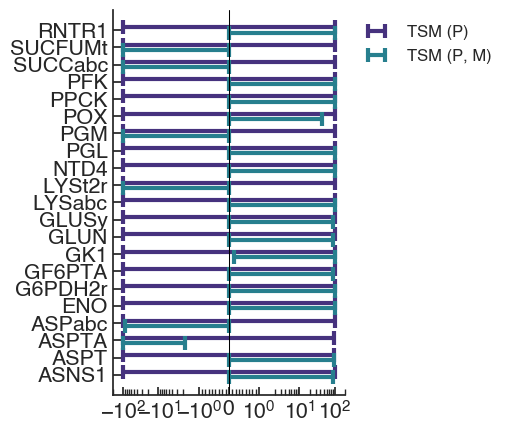

In [200]:
fig,axes=plt.subplots(figsize=(3,5))
plotbarplot2(rxn_irr_wmet,nomet_bounds,axes,offset=0.15,color=sns.color_palette('viridis')[0],label='TSM (P)',linewidth=3)
plotbarplot2(rxn_irr_wmet,df_vbounds,axes,offset=-0.15,color=sns.color_palette('viridis')[2],label='TSM (P, M)',linewidth=3)
scale_rcparams(fig,scalingf=0.5)
axes.axvline(0, color='black')
axes.set_yticks(range(len(rxn_irr_wmet)))
axes.set_yticklabels(rxn_irr_wmet)#,fontsize=25*2/3)
# axes.set_xticklabels(axes.get_xticklabels(),fontsize=25*2/3)


#x axis
axes.set_xscale('symlog',linthresh=1.3)
##set minor ticks on the symlog x axis
axes.tick_params(axis='x', which='minor', bottom=True)
axes.xaxis.set_minor_locator(io_func.MinorSymLogLocator(1e-1))
axes.set_xlim(-200,200)
handles,labels=axes.get_legend_handles_labels()
unique=[(h,l) for i ,(h,l) in enumerate(zip(handles,labels)) if l not in labels[:i]]
axes.legend(*zip(*unique),frameon=False,bbox_to_anchor=(1., 1)) ## dont forget to zip
# plt.savefig(f'{OUTPUT_FOLDER}/ecoli_vrange_metabolomecomparison.png',dpi=300)
# plt.savefig(f'{OUTPUT_FOLDER}/ecoli_vrange_metabolomecomparison.svg',dpi=300)

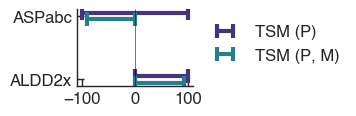

In [201]:
### actually it is going to be an inset plot for plot below 
## so we will focus on two reactions that are there : ENO and ASPTA
rxn_focus=['ALDD2x','ASPabc']

fig,axes=plt.subplots(figsize=(1.5,1))
plotbarplot2(rxn_focus,nomet_bounds,axes,offset=0.05,color=sns.color_palette('viridis')[0],label='TSM (P)',linewidth=3)
plotbarplot2(rxn_focus,df_vbounds,axes,offset=-0.05,color=sns.color_palette('viridis')[2],label='TSM (P, M)',linewidth=3)
scale_rcparams(fig,scalingf=0.25)
axes.axvline(0, color='black')
axes.set_yticks([0,1])
axes.set_yticklabels(rxn_focus)#,fontsize=25*2/3)
# axes.set_xticklabels(axes.get_xticklabels(),fontsize=25*2/3)


#x axis
# axes.set_xscale('symlog',linthresh=1.3)
##set minor ticks on the symlog x axis
axes.tick_params(axis='x', which='minor', bottom=True)
# axes.xaxis.set_minor_locator(io_func.MinorSymLogLocator(1e-1))
axes.set_xlim(-110,110)
handles,labels=axes.get_legend_handles_labels()
unique=[(h,l) for i ,(h,l) in enumerate(zip(handles,labels)) if l not in labels[:i]]
axes.legend(*zip(*unique),frameon=False,bbox_to_anchor=(1., 1))
# plt.savefig(f'{OUTPUT_FOLDER}/ecoli_vrange_inset2rxn_metabolomecomparison.png',dpi=300)
# plt.savefig(f'{OUTPUT_FOLDER}/ecoli_vrange_inset2rxn_metabolomecomparison.svg',dpi=300)

### then compare reaction directions between thermoflux metabolome and init directions from Bigg, for two conditions

In [203]:
incorrect=df_compare[(df_compare['tfva_dir']=='Backward') & (df_compare['init_dir']=='Forward')].index
for rid in incorrect: 
    # print(tmodel.reactions.get_by_id(rid).reaction)
    print(ecolimodel_bigg.reactions.get_by_id(rid).reaction)

asp__L_e + atp_c + h2o_c --> adp_c + asp__L_c + h_c + pi_c
gal_e + h_e --> gal_c + h_c
glyc3p_e + pi_c --> glyc3p_c + pi_e
2.0 h_c + no3_c + q8h2_c --> h2o_c + 2.0 h_e + no2_c + q8_c
atp_c + h2o_c + succ_e --> adp_c + h_c + pi_c + succ_c
h2o_e + tre_e --> 2.0 glc__D_e


In [167]:
incorrect=mismatch[(mismatch['tfva_dir']=='Blocked') & (mismatch['init_dir']!='Blocked')].index
for rid in incorrect: 
    # print(tmodel.reactions.get_by_id(rid).reaction)
    print(rid,ecolimodel_bigg.reactions.get_by_id(rid).reaction)

DMPPS h2mb4p_c + h_c + nadh_c --> dmpp_c + h2o_c + nad_c
DMSOR1 dmso_c + mql8_c --> dms_c + h2o_c + mqn8_c
DMSOR1e dmso_e + mql8_c --> dms_e + h2o_e + mqn8_c
DMSOR2 2dmmql8_c + dmso_c --> 2dmmq8_c + dms_c + h2o_c
DMSOR2e 2dmmql8_c + dmso_e --> 2dmmq8_c + dms_e + h2o_e
FRUK atp_c + f1p_c --> adp_c + fdp_c + h_c
FRUpts fru_e + pep_c --> f1p_c + pyr_c
FRUpts2 fru_e + pep_c --> f6p_c + pyr_c
GLCpts glc__D_e + pep_c --> g6p_c + pyr_c
GLCDe glc__D_e + h2o_e + q8_c --> glcn_e + h_e + q8h2_c
GLCNt2r glcn_e + h_e <=> glcn_c + h_c
GLCt2 glc__D_e + h_e --> glc__D_c + h_c
GNK atp_c + glcn_c --> 6pgc_c + adp_c + h_c
IPDPS h2mb4p_c + h_c + nadh_c --> h2o_c + ipdp_c + nad_c
TREpts pep_c + tre_e --> pyr_c + tre6p_c
TMAOR1 h_c + mql8_c + tmao_c --> h2o_c + mqn8_c + tma_c
TMAOR1e h_e + mql8_c + tmao_e --> h2o_e + mqn8_c + tma_e
TMAOR2 2dmmql8_c + h_c + tmao_c --> 2dmmq8_c + h2o_c + tma_c
TMAOR2e 2dmmql8_c + h_e + tmao_e --> 2dmmq8_c + h2o_e + tma_e
TREHe h2o_e + tre_e --> 2.0 glc__D_e


In [ ]:
## also add a tfva dir for other condition 
condition='AC'
metabolome=True
df_vbounds_ac=pd.read_csv(f'ecoli_{condition}_vbounds_metabolome{metabolome}.csv',index_col=1)
df_vbounds_ac.drop('Unnamed: 0',axis=1,inplace=True)

# df_vbounds[abs(df_vbounds)<1e-6]=0
metabolome=False
nomet_bounds_ac=pd.read_csv(f'ecoli_{condition}_vbounds_metabolome{metabolome}.csv',index_col=1)
nomet_bounds_ac.drop('Unnamed: 0',axis=1,inplace=True)

for rxn in nomet_bounds_ac.index:
    if df_vbounds_ac.loc[rxn,'lb']<nomet_bounds_ac.loc[rxn,'lb']:
        print(rxn,'lb',df_vbounds_ac.loc[rxn,'lb'],nomet_bounds_ac.loc[rxn,'lb'])
        df_vbounds_ac.loc[rxn,'lb']=nomet_bounds_ac.loc[rxn,'lb']
    if df_vbounds_ac.loc[rxn,'ub']>nomet_bounds_ac.loc[rxn,'ub']:
        df_vbounds_ac.loc[rxn,'ub']=nomet_bounds_ac.loc[rxn,'ub']
        print(rxn,'ub',df_vbounds_ac.loc[rxn,'ub'],nomet_bounds_ac.loc[rxn,'ub'])
# metabolome=True
# df_vbounds_ac.to_csv(f'{PLOTTING_DATA_FOLDER}/ecoli_{condition}_vbounds_metabolome{metabolome}_withcorrection.csv')

df_compare['tfva_dir_ac']=df_vbounds_ac.loc[common_rxns].apply(dir_from_bounds,axis=1)


AACPS2 ub 9.995501715759904 9.995501715759904
AACPS4 ub 13.993702402063866 13.993702402063866
AACPS5 ub 99.95501715759904 99.95501715759904
ABTA lb -100.0 -0.0138418032775007
ABUTD ub 99.98605183181364 99.98605183181364
ACCOACr lb -100.0 -97.0446043577428
ACCOACr ub 99.09998386743658 99.09998386743658
ACGK lb -100.0 0.0
ACGS lb -100.0 0.0
ACGS ub 99.02040141055608 99.02040141055608
ACHBS lb 0.0741439639230563 0.0741439639232197
ACLS lb 0.2229850164857537 0.2229850164861578
ACOATA ub 99.9990000000002 99.9990000000002
ACOTA lb -100.0 -99.15364428740102
ACOTA ub 0.0 0.0
ADA lb -100.0 0.0
ADA ub 99.9233851759345 99.9233851759345
ADCL lb 0.0134318775223058 0.0134318775223363
ADCS lb 0.0134318775223079 0.0134318775223302
ADD lb -100.0 0.0
ADD ub 99.32797192456135 99.32797192456135
ADPT ub 99.74373614864597 99.74373614864597
ADSK lb 0.0626083988694217 0.0626083988695357
ADSL1r lb -100.0 0.0749496229487221
ADSL2r lb 0.1321989563124807 0.132198956312719
ADSS lb -100.0 0.0749496230562272
ADSS ub

##focus on rxn where ac and glc are different 

In [213]:
heatmap_df = df_compare[
    df_compare["tfva_dir"] != df_compare["tfva_dir_ac"]
][["init_dir", "tfva_dir", "tfva_dir_ac"]]
#
heatmap_df
dir_map = {
    "Forward": 0,
    "Backward": 1,
    "Reversible": 2,
    "Blocked": 3
}

heat_num = heatmap_df.replace(dir_map)
heat_num.drop_duplicates(inplace=True, keep="first")


Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


In [214]:
priority = ["ASPabc", "G6PDH2r"]

heat_num = pd.concat(
    [
        heat_num.loc[priority],
        heat_num.drop(index=priority)
    ]
)

KeyError: "['G6PDH2r'] not in index"

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


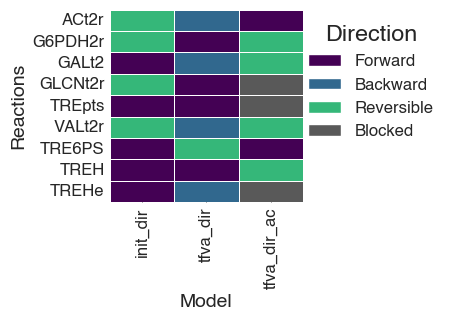

In [210]:
plt.figure(figsize=(2.5, 2.5))
from matplotlib.colors import ListedColormap
from matplotlib import cm
import numpy as np

# get exactly 4 colors from viridis,far apart
viridis = cm.get_cmap("viridis")

colors = viridis(np.linspace(0, 1, 4))
colors[-1]= [0.35, 0.35, 0.35, 1.0]
cmap = ListedColormap(colors)

ax = sns.heatmap(
    heat_num,
    cmap=cmap,
    cbar=False,
    linewidths=0.5,
    linecolor="white",
)

ax.set_xlabel("Model")
ax.set_ylabel("Reactions")

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=cmap.colors[0], label="Forward"),
    Patch(facecolor=cmap.colors[1], label="Backward"),
    Patch(facecolor=cmap.colors[2], label="Reversible"),
    Patch(facecolor=cmap.colors[3], label="Blocked"),
]

ax.legend(
    handles=legend_elements,
    title="Direction",
    bbox_to_anchor=(1.75, 1),
    frameon=False,
)
# plt.savefig(f'{OUTPUT_FOLDER}/ecoli_rxndirs_conditioncomparison.png',dpi=300)
# plt.savefig(f'{OUTPUT_FOLDER}/ecoli_rxndirs_conditioncomparison.svg',dpi=300)

In [ ]:
# df_compare.to_csv(f'{PLOTTING_DATA_FOLDER}/ecoli_dfcompare_directions_{condition}.csv')


In [216]:
mismatch = df_compare[df_compare['tfva_dir'] != df_compare['init_dir']]
mismatch.groupby(['tfva_dir', 'init_dir']).size()


tfva_dir    init_dir  
Backward    Forward         6
            Reversible     24
Blocked     Forward        13
Forward     Reversible     19
Reversible  Forward       202
dtype: int64

In [130]:
##save df compare in datafor plotting
df_compare.to_csv(f'{PLOTTING_DATA_FOLDER}/ecoli_dfcompare_directions.csv')

### GLC : 
out of 534 common reactions (that are both in our model and the initial one from the BiGG database):
- 6 incorrectly labeled (opposite direction between tfva and predefined one ), 
- 43 that are more constrained with TFVA (direction is fixed in TFVA)
- 13 additional are blocked with TFVA
- 202 less constrained with TFVA
- rest : similar


## AC : 
534 common reactions 
- 3 incorrectly labeled
- 36 more constrained with TFVA 
- 20 are blocked with TFVA
- 226 less constrained with TFVA 
- rest : similar


## which reactions are more constrained specifically

In [112]:
### read subsystem from model.xlxsx file 
subsystems_int=pd.read_excel(INPUT_MODEL,index_col=0,sheet_name='subsystems')
subsystems_int = subsystems_int.loc[~subsystems_int.index.duplicated()]
subsystems_transport_full=pd.read_excel(INPUT_MODEL,index_col=0,sheet_name='Transmembrane reactions')
subsystems_transport=subsystems_transport_full['Subsystem']
subsystems=pd.concat([subsystems_int,subsystems_transport])

In [113]:
for rid in df_compare.index.intersection(subsystems.index):
    # print(rid)
    df_compare.loc[rid,'Subsystem']=subsystems.loc[rid,'Subsystem']

In [114]:
df_plot = df_compare.drop(columns=["nomet_dir"])
df_long = df_plot.reset_index(names="reaction").melt(
    id_vars=["reaction", "Subsystem"],
    value_vars=["init_dir", "tfva_dir", "tfva_dir_ac"],
    var_name="condition",
    value_name="direction"
)
df_long

,reaction,Subsystem,condition,direction
0,ALAabc,"Transport, Extracellular",init_dir,Forward
1,ALDD2x,Alternate Carbon Metabolism,init_dir,Forward
2,ABTA,Arginine and Proline Metabolism,init_dir,Forward
3,ABUTD,Arginine and Proline Metabolism,init_dir,Forward
4,AMALT1,Alternate Carbon Metabolism,init_dir,Forward
...,...,...,...,...
1597,SGSAD,Arginine and Proline Metabolism,tfva_dir_ac,Reversible
1598,SHK3Dr,"Tyrosine, Tryptophan, and Phenylalanine Metabo...",tfva_dir_ac,Forward
1599,SHKK,"Tyrosine, Tryptophan, and Phenylalanine Metabo...",tfva_dir_ac,Forward
1600,SHSL1,Methionine Metabolism,tfva_dir_ac,Forward
